In [ ]:
from transformers import AutoProcessor, AutoModelForImageTextToText
import torch
from PIL import Image
import matplotlib.pyplot as plt
import re

# 1. Cargar modelo
model_id = "allenai/Molmo2-8B"

processor = AutoProcessor.from_pretrained(
    model_id,
    trust_remote_code=True,
    device_map="auto"
)

model = AutoModelForImageTextToText.from_pretrained(
    model_id,
    trust_remote_code=True,
    device_map="auto"
)

Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.


Loading checkpoint shards:   0%|          | 0/8 [00:00<?, ?it/s]

In [ ]:
# 2. Cargar imagen
ruta_imagen = "alm_1.png"
#"repo_fibonacci_AZ_040_EL_-16_IND_16.jpg"
imagen = Image.open(ruta_imagen).convert("RGB")

# 3. Prompt
messages = [
    {
        "role": "user",
        "content": [
            {"type": "text", "text": "Find the points where the main axis of symmetry intersects the edges of the shape."},
            {"type": "image", "image": imagen}
        ],
    }
]

inputs = processor.apply_chat_template(
    messages,
    tokenize=True,
    add_generation_prompt=True,
    return_tensors="pt",
    return_dict=True,
)

inputs = {k: v.to(model.device) for k, v in inputs.items()}

Respuesta modelo:
<points coords="1 1 452 283 2 452 695 3 454 348 4 454 638">symmetry intersection points</points>

Se detectaron 4 puntos.
ID=1 | X=452.0 | Y=283.0
ID=2 | X=452.0 | Y=695.0
ID=3 | X=454.0 | Y=348.0
ID=4 | X=454.0 | Y=638.0


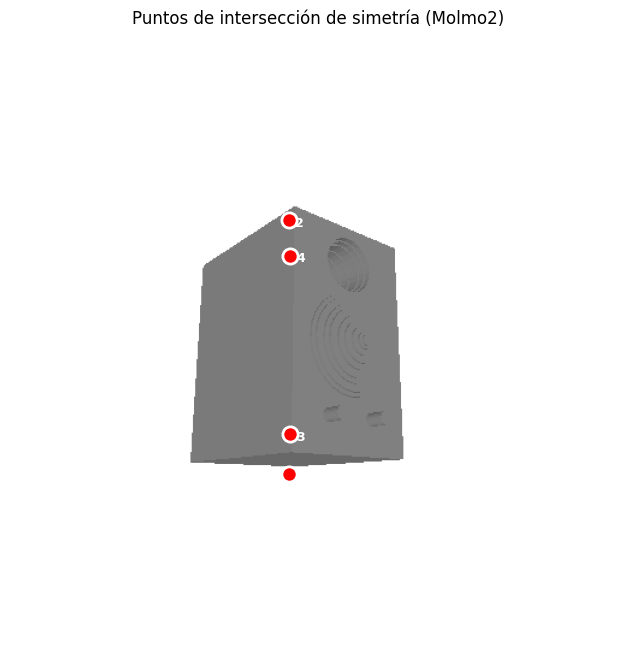

In [ ]:
# 4. Generación
with torch.inference_mode():
    output = model.generate(**inputs, max_new_tokens=200)

result = processor.tokenizer.decode(
    output[0, inputs['input_ids'].size(1):],
    skip_special_tokens=True
)

print("Respuesta modelo:")
print(result)



# 5. Extraer coordenadas 
# Formato: [radio, ID, X, Y, ID, X, Y, ...]
import re

def extract_coords(text):
    match = re.search(r'coords="([^"]+)"', text)
    if not match:
        return []
    
    raw_numbers = [float(n) for n in match.group(1).split()]
    
    if len(raw_numbers) < 4:
        return []
    
    # primer número (radio)
    raw_numbers = raw_numbers[1:]
    
    points = []
    
    for i in range(0, len(raw_numbers), 3):
        if i + 2 < len(raw_numbers):
            obj_id = int(raw_numbers[i])     # ID
            x = raw_numbers[i + 1]           # X
            y = raw_numbers[i + 2]           # Y
            
            points.append((obj_id, x, y))
    
    return points



# 6. Visualizar
import matplotlib.pyplot as plt

def visualize_points(img, points, show_labels=True):
    width, height = img.size
    
    plt.figure(figsize=(8, 8))
    plt.imshow(img)
    
    for obj_id, x, y in points:
        # Escalar desde 0–1000
        real_x = x * (width / 1000)
        real_y = y * (height / 1000)
        
        # Invertir eje Y
        real_y = height - real_y
        
        plt.scatter(
            real_x, real_y,
            s=120,
            edgecolors='white',
            c='red',
            linewidths=2,
            zorder=10
        )
        
        # Mostrar ID
        if show_labels:
            plt.text(
                real_x + 5, real_y + 5,
                f"{obj_id}",
                color='white',
                fontsize=9,
                weight='bold'
            )

    plt.title("Puntos de intersección de simetría (Molmo2)")
    plt.axis('off')
    plt.show()



# 7. Ejecutar visualización
puntos = extract_coords(result)

if puntos:
    print(f"\nSe detectaron {len(puntos)} puntos.")
    
    for p in puntos:
        print(f"ID={p[0]} | X={p[1]} | Y={p[2]}")
    
    visualize_points(imagen, puntos)

else:
    print("No se encontraron coordenadas.")

In [ ]:
# 8. Guardar imagen con puntos
import matplotlib.pyplot as plt

def save_points_image(img, points, output_path="resultado.png", show_labels=True):
    width, height = img.size
    
    plt.figure(figsize=(8, 8))
    plt.imshow(img)
    
    for obj_id, x, y in points:
        # Escalar
        real_x = x * (width / 1000)
        real_y = y * (height / 1000)
        
        # Invertir eje Y
        real_y = height - real_y
        
        plt.scatter(
            real_x, real_y,
            s=120,
            edgecolors='white',
            c='red',
            linewidths=2,
            zorder=10
        )
        
        if show_labels:
            plt.text(
                real_x + 5, real_y + 5,
                f"{obj_id}",
                color='white',
                fontsize=9,
                weight='bold'
            )

    plt.title("Puntos de simetría")
    plt.axis('off')
    
    # Guardar imagen
    plt.savefig(output_path, bbox_inches='tight', pad_inches=0)
    plt.close()

    print(f"Imagen guardada en: {output_path}")



# Ejecutar guardado
if puntos:
    save_points_image(imagen, puntos, output_path="gato_3d_resultado.png")
else:
    print("No hay puntos para guardar.")

Imagen guardada en: gato_3d_resultado.png
